In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pandas as pd
from pathlib import Path
from collections import Counter
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve, 
                             confusion_matrix, accuracy_score, balanced_accuracy_score, 
                             f1_score, classification_report)

# ============ Configuration ============
# Fixed canvas length for random placement
FIXED_LENGTH = 25565

# Minimum samples per class (filter rare classes)
MIN_CLASS_COUNT = 20

# RC fusion strategy: "early" (after first conv) or "late" (after pooling, supervisor style)
RC_FUSION_MODE = "late"

# Label smoothing factor (0.0 = no smoothing)
LABEL_SMOOTHING = 0.1

## Load Data

In [24]:
def read_fasta(path):
    """Read FASTA file and return headers and sequences."""
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line: 
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
            
    return headers, sequences

def load_multiclass_labels(label_path):
    """
    Parse a label file into a dict: header -> tag (string).
    Expected format: >header\ttag or header tag [other columns ignored]
    """
    label_path = Path(label_path)
    d = {}
    with label_path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            header = parts[0].lstrip('>')
            tag = parts[1]
            d[header] = tag
    return d

def filter_rare_classes(headers, sequences, tags, min_count=MIN_CLASS_COUNT, none_tag="None"):
    """
    Filter out samples from classes with fewer than min_count samples.
    Always keep the none_tag class (negative class).
    """
    tag_counts = Counter(tags)
    
    # Find classes to keep (>= min_count OR is none_tag)
    keep_tags = {t for t, c in tag_counts.items() if c >= min_count or t == none_tag}
    dropped_tags = set(tag_counts.keys()) - keep_tags
    
    if dropped_tags:
        dropped_counts = {t: tag_counts[t] for t in dropped_tags}
        print(f"Filtering rare classes (<{min_count} samples): {dropped_counts}")
    
    # Filter
    new_h, new_s, new_t = [], [], []
    for h, s, t in zip(headers, sequences, tags):
        if t in keep_tags:
            new_h.append(h)
            new_s.append(s)
            new_t.append(t)
    
    print(f"Kept {len(new_h)} samples from {len(keep_tags)} classes (dropped {len(headers) - len(new_h)} samples)")
    return new_h, new_s, new_t

def build_class_map(tags, none_tag="None"):
    """Build stable mapping tag -> class_id with none_tag at index 0 (if present)."""
    uniq = sorted(set(tags))
    if none_tag in uniq:
        uniq.remove(none_tag)
        class_names = [none_tag] + uniq
    else:
        class_names = uniq
    tag_to_id = {t: i for i, t in enumerate(class_names)}
    return tag_to_id, class_names

def compute_class_weights(y_ids, n_classes, mode="inv_sqrt", eps=1e-6):
    """
    Compute class weights for imbalanced multi-class.
      - inv:      1/freq
      - inv_sqrt: 1/sqrt(freq) (less extreme)
      - none:     uniform weights
    """
    counts = np.bincount(np.asarray(y_ids, dtype=np.int64), minlength=n_classes).astype(np.float64)
    if mode == "none":
        w = np.ones(n_classes, dtype=np.float32)
    elif mode == "inv":
        w = 1.0 / (counts + eps)
    elif mode == "inv_sqrt":
        w = 1.0 / np.sqrt(counts + eps)
    else:
        raise ValueError(f"Unknown mode={mode}")
    w = w / (w.mean() + 1e-12)  # normalize to mean=1
    return w.astype(np.float32)

## Data Processing

In [25]:
# ============ Encoding ============
# Mapping ACGT to 0-3, N to 4
ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTNacgtn", [0, 1, 2, 3, 4, 0, 1, 2, 3, 4]):
    ENCODE[ch] = idx

# Reverse complement: ACGTN -> TGCAN -> indices [3, 2, 1, 0, 4]
REV_COMP = torch.tensor([3, 2, 1, 0, 4], dtype=torch.long)

def resolve_device(requested=None):
    """Return the best available accelerator as a torch.device."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [26]:
# ============ Dataset with Fixed-Length Random Placement ============

class SeqDatasetMC(Dataset):
    """
    Multi-class sequence dataset with fixed-length random placement.
    
    Each sequence is placed at a random position within a fixed-length canvas.
    This provides:
    - Data augmentation (different position each epoch)
    - Forces model to learn boundary detection
    - Consistent tensor sizes across batches
    """
    def __init__(self, headers, sequences, label_ids, fixed_length=FIXED_LENGTH, training=True):
        self.headers = list(headers)
        self.sequences = list(sequences)
        self.label_ids = np.asarray(label_ids, dtype=np.int64)
        self.fixed_length = fixed_length
        self.training = training  # If False, place sequence at center (deterministic)
        
        # Precompute sequence lengths for boundary prediction
        self.seq_lengths = np.array([len(s) for s in sequences], dtype=np.int64)
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]
        seq_len = len(seq)
        
        # Encode sequence
        seq_bytes = seq.encode("ascii", "ignore")
        seq_idx = ENCODE[np.frombuffer(seq_bytes, dtype=np.uint8)]
        
        # Determine placement position
        max_start = max(0, self.fixed_length - seq_len)
        if self.training and max_start > 0:
            start_pos = np.random.randint(0, max_start + 1)
        else:
            start_pos = max_start // 2  # Center placement for eval
        
        end_pos = start_pos + seq_len
        
        return (
            self.headers[idx],
            seq_idx,
            int(self.label_ids[idx]),
            start_pos,
            end_pos,
            seq_len
        )

def collate_fixed_length(batch, fixed_length=FIXED_LENGTH):
    """
    Collate function for fixed-length random placement.
    
    Returns:
        headers: list of header strings
        X: (B, 5, fixed_length) one-hot encoded sequences
        mask: (B, fixed_length) True where real bases exist
        Y: (B,) class labels
        starts: (B,) start positions (normalized to [0,1])
        ends: (B,) end positions (normalized to [0,1])
        lengths: (B,) sequence lengths (normalized to [0,1])
    """
    headers, seq_idxs, labels, starts, ends, lengths = zip(*batch)
    
    B = len(batch)
    X = torch.zeros((B, 5, fixed_length), dtype=torch.float32)
    mask = torch.zeros((B, fixed_length), dtype=torch.bool)
    
    for i, (seq_idx, start, end, seq_len) in enumerate(zip(seq_idxs, starts, ends, lengths)):
        # Place sequence at the designated position
        actual_len = min(seq_len, fixed_length - start)
        if actual_len > 0:
            idx = torch.from_numpy(seq_idx[:actual_len].astype(np.int64))
            pos = torch.arange(actual_len, dtype=torch.long) + start
            X[i, idx, pos] = 1.0
            mask[i, start:start + actual_len] = (idx != 4)  # Mask out N's
    
    Y = torch.tensor(labels, dtype=torch.long)
    
    # Normalize positions to [0, 1] for regression targets
    starts_norm = torch.tensor(starts, dtype=torch.float32) / fixed_length
    ends_norm = torch.tensor(ends, dtype=torch.float32) / fixed_length
    lengths_norm = torch.tensor(lengths, dtype=torch.float32) / fixed_length
    
    return list(headers), X, mask, Y, starts_norm, ends_norm, lengths_norm

## Improved CNN Network with Auxiliary Boundary Prediction

Key improvements:
1. **Fixed-length random placement**: Sequences placed at random positions in fixed canvas
2. **Auxiliary boundary prediction**: Model predicts start/end positions (regularization)
3. **Configurable RC fusion**: Early (after first conv) or Late (after pooling)
4. **Label smoothing**: Reduces overconfidence
5. **Deeper network with residual connections**

In [27]:
# ============ Network Building Blocks ============

class ConvBlock(nn.Module):
    """Residual convolutional block with optional dilation."""
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation, bias=True)
        self.bn = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1)

    def forward(self, x):
        y = self.conv(x)
        y = F.gelu(self.bn(y))
        y = self.drop(y)
        return y + self.proj(x)

class MaskedMaxPool1d(nn.Module):
    """Max pooling that respects padding mask."""
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride

    def forward(self, x, mask):
        # Apply mask before pooling
        if mask is not None:
            m = mask.unsqueeze(1).float()
            x = x * m + (~mask.unsqueeze(1)) * (-1e9)  # Large negative for masked positions
        
        x_p = F.max_pool1d(x, self.kernel_size, self.stride)
        
        if mask is None:
            return x_p, None
        m_p = F.max_pool1d(mask.float().unsqueeze(1), self.kernel_size, self.stride).squeeze(1) > 0
        return x_p, m_p

def masked_avg_pool(z, mask):
    """Global average pooling respecting mask."""
    if mask is None:
        return z.mean(-1)
    m = mask.unsqueeze(1).float()
    return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)

In [28]:
# ============ Early RC Fusion (max after first conv) ============

class RCFirstConv1d(nn.Module):
    """
    RC-invariant first convolution layer.
    Computes max(conv(x), conv(RC(x))) for early RC fusion.
    """
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        y1 = self.conv(x)
        
        # Reverse complement
        x_rc = x.flip(-1).index_select(1, REV_COMP.to(x.device))
        y2 = self.conv(x_rc).flip(-1)
        
        # Take element-wise max for RC invariance
        y = torch.max(y1, y2)
        y = self.batch_norm(y)
        y = F.gelu(y)
        y = self.dropout(y)
        
        return y

In [29]:
# ============ Main Model with Auxiliary Boundary Prediction ============

class ImprovedRCCNN(nn.Module):
    """
    Improved RC-invariant CNN for multi-class TE classification.
    
    Features:
    - Configurable RC fusion (early or late)
    - Auxiliary boundary prediction head (start/end/length)
    - Deeper network with residual connections
    - Multi-scale motif detection
    
    Args:
        num_classes: Number of output classes
        width: Base channel width
        motif_kernels: Tuple of kernel sizes for motif detection
        context_kernel: Kernel size for context blocks
        context_dilations: Tuple of dilation rates for context blocks
        dropout: Dropout rate
        rc_mode: "early" (max after first conv) or "late" (average after pooling)
        aux_weight: Weight for auxiliary boundary prediction loss
    """
    def __init__(
        self,
        num_classes,
        width=128,
        motif_kernels=(7, 15, 21),
        context_kernel=9,
        context_dilations=(1, 2, 4, 8),
        dropout=0.15,
        rc_mode="late",
        aux_weight=0.1
    ):
        super().__init__()
        self.num_classes = int(num_classes)
        self.rc_mode = rc_mode
        self.aux_weight = aux_weight
        
        # ---- Motif detection layers ----
        if rc_mode == "early":
            # Early fusion: RC-invariant first conv
            self.motif_convs = nn.ModuleList([
                RCFirstConv1d(width, kernel_size=k, dropout=dropout)
                for k in motif_kernels
            ])
        else:
            # Late fusion: standard convs (RC handled later)
            self.motif_convs = nn.ModuleList([
                nn.Sequential(
                    nn.Conv1d(5, width, kernel_size=k, padding=k//2, bias=True),
                    nn.BatchNorm1d(width),
                    nn.GELU(),
                    nn.Dropout(dropout)
                )
                for k in motif_kernels
            ])
        
        # ---- Mix layer ----
        in_ch = width * len(motif_kernels)
        self.mix = nn.Sequential(
            nn.Conv1d(in_ch, width, kernel_size=1, bias=True),
            nn.BatchNorm1d(width),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        
        # ---- Context blocks with increasing dilation ----
        self.context_blocks = nn.ModuleList([
            ConvBlock(width, width, kernel_size=context_kernel, dilation=d, dropout=dropout)
            for d in context_dilations
        ])
        self.pool = MaskedMaxPool1d(kernel_size=2, stride=2)
        
        # ---- Classification head ----
        self.class_head = nn.Sequential(
            nn.Linear(width, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, self.num_classes),
        )
        
        # ---- Auxiliary boundary prediction head ----
        # Predicts: start_position, end_position, length (all normalized to [0,1])
        self.boundary_head = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 3),  # start, end, length
            nn.Sigmoid()  # Output in [0, 1]
        )
        
    @staticmethod
    def rc_transform(x, mask):
        """Apply reverse complement transformation."""
        x_rc = x.index_select(1, REV_COMP.to(x.device)).flip(-1)
        mask_rc = None if mask is None else mask.flip(-1)
        return x_rc, mask_rc
    
    def encode(self, x, mask):
        """Encode sequence through CNN tower."""
        # Multi-scale motif detection
        feats = [conv(x) for conv in self.motif_convs]
        z = torch.cat(feats, dim=1)
        z = self.mix(z)
        
        # Context blocks with pooling
        m = mask
        for block in self.context_blocks:
            z = block(z)
            z, m = self.pool(z, m)
        
        return masked_avg_pool(z, m)  # (B, width)
    
    def forward(self, x, mask):
        """
        Forward pass.
        
        Returns:
            class_logits: (B, num_classes) classification logits
            boundary_pred: (B, 3) predicted [start, end, length] normalized
        """
        if self.rc_mode == "late":
            # Late fusion: encode both orientations and average
            f = self.encode(x, mask)
            x_rc, mask_rc = self.rc_transform(x, mask)
            r = self.encode(x_rc, mask_rc)
            pooled = 0.5 * (f + r)
        else:
            # Early fusion: RC invariance built into first conv
            pooled = self.encode(x, mask)
        
        class_logits = self.class_head(pooled)
        boundary_pred = self.boundary_head(pooled)
        
        return class_logits, boundary_pred

## Training Functions with Label Smoothing and LR Scheduling

In [30]:
class LabelSmoothingCrossEntropy(nn.Module):
    """Cross-entropy loss with label smoothing."""
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        
    def forward(self, pred, target):
        n_classes = pred.size(-1)
        
        # One-hot encode targets
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        
        # Apply smoothing
        smooth_one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_classes
        
        # Compute log softmax
        log_prob = F.log_softmax(pred, dim=-1)
        
        # Apply class weights if provided
        if self.weight is not None:
            log_prob = log_prob * self.weight.unsqueeze(0)
        
        # Cross entropy with smoothed labels
        loss = -(smooth_one_hot * log_prob).sum(dim=-1)
        return loss.mean()

def save_checkpoint(state, path, filename):
    """Save model checkpoint with versioning."""
    os.makedirs(path, exist_ok=True)
    base_path = os.path.join(path, f"{filename}.pt")
    
    if os.path.exists(base_path):
        n = 1
        while n <= 100:
            versioned_path = os.path.join(path, f"{filename}_v{n}.pt")
            if not os.path.exists(versioned_path):
                torch.save(state, versioned_path)
                print(f"Saved checkpoint to {versioned_path}")
                return versioned_path
            n += 1
    else:
        torch.save(state, base_path)
        print(f"Saved checkpoint to {base_path}")
        return base_path

In [31]:
from sklearn.model_selection import StratifiedKFold

def run_train_improved(
    fasta_path,
    label_path,
    batch_size=32,           # Increased batch size for speed
    epochs=3,
    lr=1e-3,
    width=128,
    motif_kernels=(7, 15, 21),
    context_kernel=9,
    context_dilations=(1, 2, 4, 8),
    dropout=0.15,
    rc_mode=RC_FUSION_MODE,
    aux_weight=0.1,
    label_smoothing=LABEL_SMOOTHING,
    min_class_count=MIN_CLASS_COUNT,
    device=None,
    patience=10,
    subset_size=10000,       # Default to 10k samples for fast training
    n_folds=5,               # Number of folds for rotating train/val split
    test_size=0.2,           # Hold-out test set fraction
    random_state=42,
    weight_mode="inv_sqrt",
    save_dir="."
):
    """
    Train the improved multi-class TE classifier with rotating cross-validation.
    
    Key features:
    - Stratified subset sampling for faster training
    - Separate hold-out test set (20%)
    - Rotating K-fold train/val split across epochs
    - Fixed-length random placement & auxiliary boundary prediction
    """
    device = resolve_device(device)
    print(f"Using device: {device}")
    print(f"RC fusion mode: {rc_mode}")
    print(f"Label smoothing: {label_smoothing}")
    print(f"Auxiliary loss weight: {aux_weight}")
    print(f"Min class count: {min_class_count}")
    print(f"Subset size: {subset_size}")
    print(f"K-folds for rotating train/val: {n_folds}")
    
    # ---- Load and filter data ----
    print("\n=== Loading data ===")
    headers, sequences = read_fasta(fasta_path)
    lab = load_multiclass_labels(label_path)
    
    # Match headers to labels
    filtered_h, filtered_s, tags = [], [], []
    missing = 0
    for h, s in zip(headers, sequences):
        t = lab.get(h)
        if t is None:
            missing += 1
            continue
        filtered_h.append(h)
        filtered_s.append(s)
        tags.append(t)
    if missing:
        print(f"Dropped {missing} sequences without labels.")
    
    # Filter rare classes
    filtered_h, filtered_s, tags = filter_rare_classes(
        filtered_h, filtered_s, tags, min_count=min_class_count
    )
    
    # Build class mapping BEFORE subsetting to ensure consistent class IDs
    tag_to_id_full, class_names = build_class_map(tags, none_tag="None")
    n_classes = len(class_names)
    y_ids_full = np.asarray([tag_to_id_full[t] for t in tags], dtype=np.int64)
    
    # ---- Stratified subset sampling ----
    n_total = len(filtered_h)
    if subset_size is not None and subset_size < n_total:
        # Use stratified sampling to maintain class proportions
        rng = np.random.default_rng(random_state)
        
        # Group indices by class
        class_indices = {c: [] for c in range(n_classes)}
        for i, y in enumerate(y_ids_full):
            class_indices[y].append(i)
        
        # Sample proportionally from each class
        selected_indices = []
        for c in range(n_classes):
            c_idx = np.array(class_indices[c])
            # Proportion of this class in target subset
            n_samples_c = max(1, int(len(c_idx) / n_total * subset_size))
            n_samples_c = min(n_samples_c, len(c_idx))  # Don't exceed available
            sel_c = rng.choice(c_idx, size=n_samples_c, replace=False)
            selected_indices.extend(sel_c)
        
        selected_indices = np.sort(selected_indices)
        filtered_h = [filtered_h[i] for i in selected_indices]
        filtered_s = [filtered_s[i] for i in selected_indices]
        tags = [tags[i] for i in selected_indices]
        print(f"Stratified subset: {len(filtered_h)} / {n_total}")
        
        # IMPORTANT: Filter again after subset - some classes may now be too small
        # Need at least 2 samples per class for stratified splitting, and n_folds for K-fold
        min_after_subset = max(n_folds, 2)  # At least n_folds samples to have 1 per fold
        filtered_h, filtered_s, tags = filter_rare_classes(
            filtered_h, filtered_s, tags, min_count=min_after_subset, none_tag="None"
        )
    
    # Rebuild IDs after subset and filtering
    tag_to_id, class_names = build_class_map(tags, none_tag="None")
    y_ids = np.asarray([tag_to_id[t] for t in tags], dtype=np.int64)
    n_classes = len(class_names)
    print(f"\nClasses ({n_classes}): {class_names}")
    
    # Show class distribution
    class_counts = Counter(tags)
    print("\nClass distribution (after subset):")
    for name in class_names:
        print(f"  {name}: {class_counts[name]}")
    
    # ---- Split off TEST SET (held out entirely) ----
    idx_trainval, idx_test = train_test_split(
        np.arange(len(filtered_s)), test_size=test_size, stratify=y_ids, random_state=random_state
    )
    
    # Test set (never touched during training)
    test_h = [filtered_h[i] for i in idx_test]
    test_s = [filtered_s[i] for i in idx_test]
    test_y = y_ids[idx_test]
    
    # Train+val set (will be split with rotating folds)
    trainval_h = [filtered_h[i] for i in idx_trainval]
    trainval_s = [filtered_s[i] for i in idx_trainval]
    trainval_y = y_ids[idx_trainval]
    
    print(f"\nTrain+Val: {len(trainval_h)}, Test (held out): {len(test_h)}")
    
    # ---- Set up K-fold cross-validation for rotating train/val ----
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    fold_splits = list(skf.split(trainval_h, trainval_y))
    
    # ---- Model ----
    model = ImprovedRCCNN(
        num_classes=n_classes,
        width=width,
        motif_kernels=motif_kernels,
        context_kernel=context_kernel,
        context_dilations=context_dilations,
        dropout=dropout,
        rc_mode=rc_mode,
        aux_weight=aux_weight
    ).to(device)
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    
    # ---- Loss functions (use full trainval set for class weights) ----
    class_weights = compute_class_weights(trainval_y, n_classes, mode=weight_mode)
    class_weights_t = torch.tensor(class_weights, device=device)
    
    if label_smoothing > 0:
        class_loss_fn = LabelSmoothingCrossEntropy(smoothing=label_smoothing, weight=class_weights_t)
    else:
        class_loss_fn = nn.CrossEntropyLoss(weight=class_weights_t)
    
    boundary_loss_fn = nn.MSELoss()
    
    # ---- Optimizer and scheduler ----
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    
    # ---- Training loop with rotating folds ----
    print("\n=== Training with rotating train/val folds ===")
    history = {
        "train_loss": [], "val_loss": [], "train_cls_loss": [], "train_aux_loss": [],
        "val_acc": [], "val_bal_acc": [], "val_macro_f1": [], "fold_used": []
    }
    best_state, best_epoch = None, None
    best_macro_f1 = -math.inf
    bad = 0
    
    for ep in range(1, epochs + 1):
        # ---- Rotate fold: use fold (ep-1) % n_folds ----
        fold_idx = (ep - 1) % n_folds
        train_indices, val_indices = fold_splits[fold_idx]
        
        # Build datasets for this epoch's fold
        ds_tr = SeqDatasetMC(
            [trainval_h[i] for i in train_indices],
            [trainval_s[i] for i in train_indices],
            trainval_y[train_indices],
            training=True
        )
        ds_val = SeqDatasetMC(
            [trainval_h[i] for i in val_indices],
            [trainval_s[i] for i in val_indices],
            trainval_y[val_indices],
            training=False
        )
        
        loader_tr = DataLoader(
            ds_tr, batch_size=batch_size, shuffle=True, num_workers=0,
            collate_fn=collate_fixed_length
        )
        loader_val = DataLoader(
            ds_val, batch_size=batch_size, shuffle=False, num_workers=0,
            collate_fn=collate_fixed_length
        )
        
        # ---- Train ----
        model.train()
        running_loss, running_cls, running_aux = 0.0, 0.0, 0.0
        
        pbar = tqdm(loader_tr, desc=f"Epoch {ep}/{epochs} (fold {fold_idx+1}/{n_folds})", leave=False)
        for _, X, mask, Y, starts, ends, lengths in pbar:
            X = X.to(device)
            mask = mask.to(device)
            Y = Y.to(device)
            boundary_target = torch.stack([starts, ends, lengths], dim=1).to(device)
            
            # Forward
            class_logits, boundary_pred = model(X, mask)
            
            # Losses
            cls_loss = class_loss_fn(class_logits, Y)
            aux_loss = boundary_loss_fn(boundary_pred, boundary_target)
            loss = cls_loss + aux_weight * aux_loss
            
            # Backward
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            running_loss += loss.item() * X.size(0)
            running_cls += cls_loss.item() * X.size(0)
            running_aux += aux_loss.item() * X.size(0)
            
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        
        scheduler.step()
        
        train_loss = running_loss / len(ds_tr)
        train_cls = running_cls / len(ds_tr)
        train_aux = running_aux / len(ds_tr)
        
        # ---- Validate ----
        model.eval()
        val_running = 0.0
        all_logits, all_y = [], []
        
        with torch.no_grad():
            for _, X, mask, Y, starts, ends, lengths in loader_val:
                X = X.to(device)
                mask = mask.to(device)
                Y = Y.to(device)
                boundary_target = torch.stack([starts, ends, lengths], dim=1).to(device)
                
                class_logits, boundary_pred = model(X, mask)
                
                cls_loss = class_loss_fn(class_logits, Y)
                aux_loss = boundary_loss_fn(boundary_pred, boundary_target)
                loss = cls_loss + aux_weight * aux_loss
                
                val_running += loss.item() * X.size(0)
                all_logits.append(class_logits.cpu())
                all_y.append(Y.cpu())
        
        val_loss = val_running / len(ds_val)
        logits_np = torch.cat(all_logits, dim=0).numpy()
        y_np = torch.cat(all_y, dim=0).numpy()
        pred = logits_np.argmax(axis=1)
        
        acc = accuracy_score(y_np, pred)
        bal_acc = balanced_accuracy_score(y_np, pred)
        macro_f1 = f1_score(y_np, pred, average="macro")
        
        # Record history
        history["train_loss"].append(train_loss)
        history["train_cls_loss"].append(train_cls)
        history["train_aux_loss"].append(train_aux)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(acc)
        history["val_bal_acc"].append(bal_acc)
        history["val_macro_f1"].append(macro_f1)
        history["fold_used"].append(fold_idx + 1)
        
        print(f"Epoch {ep} (fold {fold_idx+1}): loss {train_loss:.4f} (cls {train_cls:.4f}, aux {train_aux:.4f}) | "
              f"val {val_loss:.4f} | acc {acc:.4f} | bal_acc {bal_acc:.4f} | F1 {macro_f1:.4f}")
        
        # Check for improvement
        if macro_f1 > best_macro_f1 + 1e-4:
            best_macro_f1 = macro_f1
            best_epoch = ep
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break
    
    # ---- Final evaluation on TEST SET ----
    print("\n=== Evaluating on held-out TEST SET ===")
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    
    ds_test = SeqDatasetMC(test_h, test_s, test_y, training=False)
    loader_test = DataLoader(
        ds_test, batch_size=batch_size, shuffle=False, num_workers=0,
        collate_fn=collate_fixed_length
    )
    
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for _, X, mask, Y, starts, ends, lengths in loader_test:
            X = X.to(device)
            mask = mask.to(device)
            class_logits, _ = model(X, mask)
            all_logits.append(class_logits.cpu())
            all_y.append(Y)
    
    test_logits = torch.cat(all_logits, dim=0).numpy()
    test_y_np = torch.cat(all_y, dim=0).numpy()
    test_pred = test_logits.argmax(axis=1)
    
    test_acc = accuracy_score(test_y_np, test_pred)
    test_bal_acc = balanced_accuracy_score(test_y_np, test_pred)
    test_macro_f1 = f1_score(test_y_np, test_pred, average="macro")
    
    print(f"\nTEST SET results:")
    print(f"  Accuracy: {test_acc:.4f}")
    print(f"  Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"  Macro F1: {test_macro_f1:.4f}")
    
    print("\n=== Test Set Classification Report ===")
    print(classification_report(test_y_np, test_pred, target_names=class_names, zero_division=0))
    
    # Save checkpoint
    if best_state is not None:
        ckpt = {
            "model_state_dict": best_state,
            "class_names": class_names,
            "tag_to_id": tag_to_id,
            "arch": {
                "width": width,
                "motif_kernels": tuple(motif_kernels),
                "context_kernel": int(context_kernel),
                "context_dilations": tuple(context_dilations),
                "rc_mode": rc_mode,
            },
            "best_epoch": best_epoch,
            "best_macro_f1": best_macro_f1,
            "test_macro_f1": test_macro_f1,
        }
        save_checkpoint(ckpt, save_dir, "improved_rc_cnn_best")
    
    # AUROC/AUPRC on test set
    probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
    try:
        y_onehot = np.eye(n_classes, dtype=np.int32)[test_y_np]
        auroc = roc_auc_score(y_onehot, probs, average="macro", multi_class="ovr")
        auprc = average_precision_score(y_onehot, probs, average="macro")
        print(f"\nTest Macro AUROC: {auroc:.4f} | Test Macro AUPRC: {auprc:.4f}")
    except Exception as e:
        print(f"Could not compute AUROC/AUPRC: {e}")
        auroc, auprc = None, None
    
    return {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_val_macro_f1": best_macro_f1,
        "test_acc": test_acc,
        "test_bal_acc": test_bal_acc,
        "test_macro_f1": test_macro_f1,
        "class_names": class_names,
        "tag_to_id": tag_to_id,
        "device": str(device),
        "auroc": auroc,
        "auprc": auprc,
    }

In [32]:
# ============ Data Paths (updated for new location) ============
# Notebook is now in: data_analysis/vgp_model_data_tpase_multi/
# Data is in: data/vgp/

FASTA_PATH = '../../data/vgp/all_vgp_tes.fa'
LABEL_PATH = '../../data/vgp/features-tpase'

# Verify paths exist
from pathlib import Path
assert Path(FASTA_PATH).exists(), f"FASTA file not found: {FASTA_PATH}"
assert Path(LABEL_PATH).exists(), f"Label file not found: {LABEL_PATH}"

print(f"FASTA: {Path(FASTA_PATH).resolve()}")
print(f"Labels: {Path(LABEL_PATH).resolve()}")

FASTA: /Users/alexyang/Documents/Part III System Biology/TE Classification/data/vgp/all_vgp_tes.fa
Labels: /Users/alexyang/Documents/Part III System Biology/TE Classification/data/vgp/features-tpase


In [33]:
# ============ Run Training ============
# subset_size=10000 for fast testing (~10k samples)
# n_folds=5 for rotating train/val split
# test_size=0.2 for held-out test set
# batch_size=32 for faster iteration

results = run_train_improved(
    fasta_path=FASTA_PATH,
    label_path=LABEL_PATH,
    
    # Training params (optimized for speed)
    batch_size=32,           # Larger batch = fewer iterations
    epochs=3,                # Quick test
    lr=1e-3,
    patience=10,
    
    # Subset & split params
    subset_size=10000,       # Use ~10k samples (vs 130k full) 
    n_folds=5,               # 5-fold rotating train/val
    test_size=0.2,           # 20% held-out test set
    
    # Model architecture
    width=128,
    motif_kernels=(7, 15, 21),
    context_kernel=9,
    context_dilations=(1, 2, 4, 8),
    dropout=0.15,
    
    # Key improvements
    rc_mode=RC_FUSION_MODE,
    aux_weight=0.1,
    label_smoothing=LABEL_SMOOTHING,
    min_class_count=MIN_CLASS_COUNT,
    
    # Other
    weight_mode="inv_sqrt",
    random_state=42,
    save_dir=".",
)

Using device: mps
RC fusion mode: late
Label smoothing: 0.1
Auxiliary loss weight: 0.1
Min class count: 20
Subset size: 10000
K-folds for rotating train/val: 5

=== Loading data ===
Filtering rare classes (<20 samples): {'DNA/Ginger-1': 4, 'DNA/Merlin': 12, 'DNA/Dada': 2, 'DNA/Crypton-V': 19}
Kept 135714 samples from 14 classes (dropped 37 samples)
Stratified subset: 9993 / 135714
Filtering rare classes (<5 samples): {'DNA/PIF-ISL2EU': 2, 'DNA/Sola-1': 3, 'DNA/MULE-MuDR': 1}
Kept 9987 samples from 11 classes (dropped 6 samples)

Classes (11): ['None', 'DNA', 'DNA/Academ-1', 'DNA/CMC', 'DNA/Kolobok', 'DNA/P', 'DNA/PIF-Harbinger', 'DNA/PiggyBac', 'DNA/Sola-2', 'DNA/TcMar-Tc1', 'DNA/hAT']

Class distribution (after subset):
  None: 9217
  DNA: 112
  DNA/Academ-1: 30
  DNA/CMC: 13
  DNA/Kolobok: 6
  DNA/P: 5
  DNA/PIF-Harbinger: 58
  DNA/PiggyBac: 41
  DNA/Sola-2: 6
  DNA/TcMar-Tc1: 138
  DNA/hAT: 361

Train+Val: 7989, Test (held out): 1998

Model parameters: 713,870

=== Training with rot

/Users/alexyang/Documents/Part III System Biology/TE Classification/.venv/lib/python3.11/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Epoch 1/3 (fold 1/5):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 1 (fold 1): loss 0.4128 (cls 0.4076, aux 0.0523) | val 0.3933 | acc 0.9230 | bal_acc 0.0909 | F1 0.0873


Epoch 2/3 (fold 2/5):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 2 (fold 2): loss 0.3984 (cls 0.3939, aux 0.0456) | val 0.3962 | acc 0.9230 | bal_acc 0.0909 | F1 0.0873


Epoch 3/3 (fold 3/5):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 3 (fold 3): loss 0.3970 (cls 0.3926, aux 0.0447) | val 0.3924 | acc 0.9230 | bal_acc 0.0909 | F1 0.0873

=== Evaluating on held-out TEST SET ===

TEST SET results:
  Accuracy: 0.9229
  Balanced Accuracy: 0.0909
  Macro F1: 0.0873

=== Test Set Classification Report ===
                   precision    recall  f1-score   support

             None       0.92      1.00      0.96      1844
              DNA       0.00      0.00      0.00        22
     DNA/Academ-1       0.00      0.00      0.00         6
          DNA/CMC       0.00      0.00      0.00         3
      DNA/Kolobok       0.00      0.00      0.00         1
            DNA/P       0.00      0.00      0.00         1
DNA/PIF-Harbinger       0.00      0.00      0.00        12
     DNA/PiggyBac       0.00      0.00      0.00         8
       DNA/Sola-2       0.00      0.00      0.00         1
    DNA/TcMar-Tc1       0.00      0.00      0.00        28
          DNA/hAT       0.00      0.00      0.00        72

         accur

## Plot the results

In [34]:
def plot_training_curves(history):
    """Plot training and validation curves."""
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)
    if len(epochs) == 0:
        raise ValueError("History is empty; run training first.")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Loss curves
    axes[0].plot(epochs, history["train_loss"], label="Train total", marker="o")
    axes[0].plot(epochs, history["train_cls_loss"], label="Train class", marker="s", alpha=0.7)
    axes[0].plot(epochs, history["train_aux_loss"], label="Train boundary", marker="^", alpha=0.7)
    axes[0].plot(epochs, history["val_loss"], label="Val total", marker="o")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss curves")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(epochs, history["val_acc"], label="Accuracy", marker="o")
    axes[1].plot(epochs, history["val_bal_acc"], label="Balanced Acc", marker="s")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Validation Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # F1 curve
    axes[2].plot(epochs, history["val_macro_f1"], label="Macro F1", marker="o", color="green")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Score")
    axes[2].set_ylim(0, 1)
    axes[2].set_title("Validation Macro F1")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    fig.tight_layout()
    return fig, axes

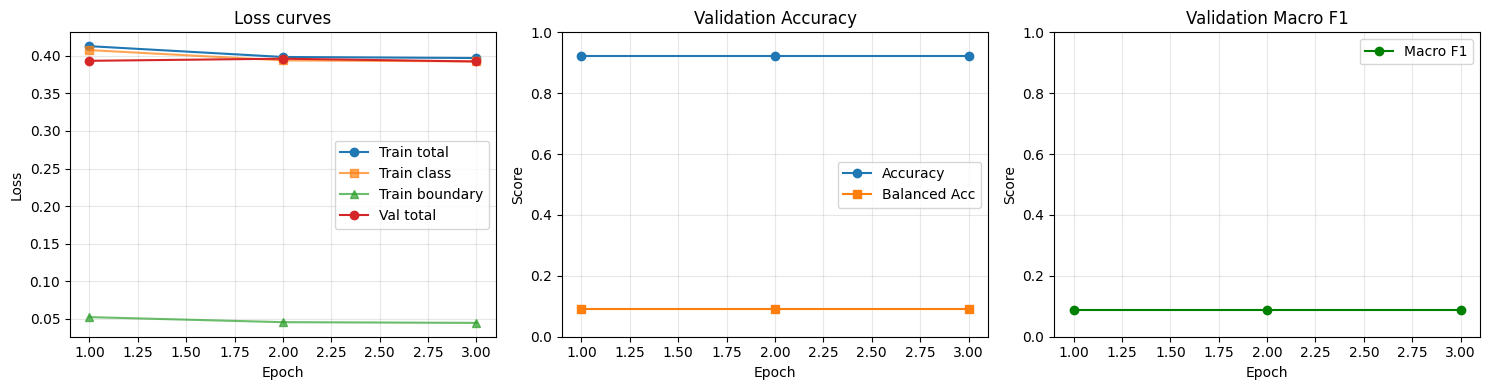


Best epoch: 1 (fold 1)
Best validation macro F1: 0.0873

=== HELD-OUT TEST SET ===
Test Accuracy: 0.9229
Test Balanced Accuracy: 0.0909
Test Macro F1: 0.0873


In [35]:
# Plot training curves
fig, axes = plot_training_curves(results["history"])
plt.show()

print(f"\nBest epoch: {results['best_epoch']} (fold {results['history']['fold_used'][results['best_epoch']-1]})")
print(f"Best validation macro F1: {results['best_val_macro_f1']:.4f}")
print(f"\n=== HELD-OUT TEST SET ===")
print(f"Test Accuracy: {results['test_acc']:.4f}")
print(f"Test Balanced Accuracy: {results['test_bal_acc']:.4f}")
print(f"Test Macro F1: {results['test_macro_f1']:.4f}")